<a href="https://colab.research.google.com/github/snehalmore/GEE_colab/blob/main/Icesat2_AEE_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initiation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import os

In [4]:
output_directory = '/content/drive/MyDrive/Earth_Engine_Exports/'

# Data Prep

In [9]:
file_path = "/content/drive/MyDrive/Data/ICESAT/is24.parquet"
input_file = pd.read_parquet(file_path)

In [8]:
# display(df.head().T)
display(input_file.columns.tolist())

['delta_time',
 'filename',
 'sc_orient',
 'beam',
 'segment_landcover',
 'rgt',
 'start_cycle',
 'end_cycle',
 'segment_id_beg',
 'segment_id_end',
 'lat',
 'lon',
 'h_canopy',
 'canopy_openness',
 'h_mean_canopy',
 'h_median_canopy',
 'h_dif_canopy',
 'h_min_canopy',
 'h_max_canopy',
 'toc_roughness',
 'h_canopy_quad',
 'n_ca_photons',
 'n_toc_photons',
 'centroid_height',
 'h_canopy_uncertainty',
 'can_noise',
 'dem_h',
 'h_te_best_fit',
 'h_te_interp',
 'h_te_mean',
 'h_te_median',
 'h_te_max',
 'h_te_min',
 'n_te_photons',
 'terrain_slope',
 'brightness_flag',
 'cloud_flag',
 'cloud_fold_flag',
 'dem_flag',
 'dem_removal_flag',
 'layer_flag',
 'msw_flag',
 'night_flag',
 'ph_removal_flag',
 'psf_flag',
 'sat_flag',
 'segment_watermask',
 'snr',
 'terrain_flag',
 'urban_flag',
 'lat_0_20',
 'lat_20_40',
 'lat_40_60',
 'lat_60_80',
 'lat_80_100',
 'long_0_20',
 'long_20_40',
 'long_40_60',
 'long_60_80',
 'long_80_100',
 'h_canopy_0_20',
 'h_canopy_20_40',
 'h_canopy_40_60',
 'h_can

##Read raster data AEE
Alpha earth embedding raster valuee vectors if length 64 corresponding to geoSegmentUID

In [10]:

# Define the base path for your CSV files in Google Drive
# Please adjust this path and the file prefix if your files are located differently
csv_base_path = '/content/drive/MyDrive/Earth_Engine_Exports/'
file_prefix = 'Embedding_Extract_2024_Chunk_'

# List to hold individual AEE_chunks
AEE_chunks = []

# Loop from 0 to 10 to read and merge CSV files
for i in range(228):
    file_name = f"{file_prefix}{i}.csv"
    file_path = os.path.join(csv_base_path, file_name)

    if os.path.exists(file_path):
        print(f"Reading {file_name}...")
        try:
            df = pd.read_csv(file_path)
            AEE_chunks.append(df)
        except Exception as e:
            print(f"Error reading {file_name}: {e}")
    else:
        print(f"File not found: {file_name}")

# Merge all AEE_chunks into one
if AEE_chunks :
    merged_AEE_data = pd.concat(AEE_chunks, ignore_index=True)
    # Rename 'geosegment' column to 'geosegmentUID'
    merged_AEE_data = merged_AEE_data.rename(columns={'geosegment': 'geosegmentUID'})
    print("Successfully merged all available CSV files.")
    display(merged_AEE_data.head())
    print(f"Total rows in merged DataFrame: {len(merged_AEE_data)}")
else:
    print("No CSV files were found or successfully read to merge.")

Reading Embedding_Extract_2024_Chunk_0.csv...
Reading Embedding_Extract_2024_Chunk_1.csv...
Reading Embedding_Extract_2024_Chunk_2.csv...
Reading Embedding_Extract_2024_Chunk_3.csv...
Reading Embedding_Extract_2024_Chunk_4.csv...
Reading Embedding_Extract_2024_Chunk_5.csv...
Reading Embedding_Extract_2024_Chunk_6.csv...
Reading Embedding_Extract_2024_Chunk_7.csv...
Reading Embedding_Extract_2024_Chunk_8.csv...
Reading Embedding_Extract_2024_Chunk_9.csv...
Reading Embedding_Extract_2024_Chunk_10.csv...
Reading Embedding_Extract_2024_Chunk_11.csv...
Reading Embedding_Extract_2024_Chunk_12.csv...
Reading Embedding_Extract_2024_Chunk_13.csv...
Reading Embedding_Extract_2024_Chunk_14.csv...
Reading Embedding_Extract_2024_Chunk_15.csv...
Reading Embedding_Extract_2024_Chunk_16.csv...
Reading Embedding_Extract_2024_Chunk_17.csv...
Reading Embedding_Extract_2024_Chunk_18.csv...
Reading Embedding_Extract_2024_Chunk_19.csv...


KeyboardInterrupt: 

Save AEE file into one CSV


In [13]:
output_directory = '/content/drive/MyDrive/Earth_Engine_Exports/'
output_filename = 'AEE_2024_complete.csv'
output_file_path = os.path.join(output_directory, output_filename)

# Create the directory if it does not exist
os.makedirs(output_directory, exist_ok=True)

merged_AEE_data.to_csv(output_file_path, index=False)

print(f"DataFrame successfully saved to: {output_file_path}")

KeyboardInterrupt: 

## canopy hieght and embedding dataset
Create a canopy hieght and embedding dataset at 20m segemgents along the track.

 - first we read the dataset with canopy heights - if geosegmentUID value contains _40_60 at end then we assign canopy height from h_canopy_40_60 and so on.

 - we ignore the rows with h canpy height value =  340282346638528859811704183484516925440.0

In [11]:
columns_to_select = [
 'lat',
 'lon',
 'h_canopy',
 'canopy_openness',
 'h_mean_canopy',
 'h_median_canopy',
 'h_dif_canopy',
 'h_min_canopy',
 'h_max_canopy',
 'toc_roughness',
 'dem_h',
 'lat_0_20',
 'lat_20_40',
 'lat_40_60',
 'lat_60_80',
 'lat_80_100',
 'long_0_20',
 'long_20_40',
 'long_40_60',
 'long_60_80',
 'long_80_100',
 'h_canopy_0_20',
 'h_canopy_20_40',
 'h_canopy_40_60',
 'h_canopy_60_80',
 'h_canopy_80_100',
 'datetime',
 'year',
 'month',
 'segmentUID',
 'geoseg_latitude',
 'geoseg_longitude',
 'geoseg_h_canopy',
 'geosegmentUID',
]

# Create the subset DataFrame with the specified columns
select_coloumns = input_file[columns_to_select]

# Display the first few rows of the new DataFrame
display(select_coloumns.head().T)

,0,1,2,3,4
lat,32.943623,32.943623,32.943623,32.943623,32.943623
lon,-79.236603,-79.236603,-79.236603,-79.236603,-79.236603
h_canopy,2.205853,2.205853,2.205853,2.205853,2.205853
canopy_openness,0.469295,0.469295,0.469295,0.469295,0.469295
h_mean_canopy,0.845882,0.845882,0.845882,0.845882,0.845882
h_median_canopy,0.676548,0.676548,0.676548,0.676548,0.676548
h_dif_canopy,1.529305,1.529305,1.529305,1.529305,1.529305
h_min_canopy,0.509758,0.509758,0.509758,0.509758,0.509758
h_max_canopy,2.205853,2.205853,2.205853,2.205853,2.205853
toc_roughness,0.0,0.0,0.0,0.0,0.0


In [14]:
merged_AEE_data_path = '/content/drive/MyDrive/Earth_Engine_Exports/AEE_2024_complete.csv'
merged_AEE_data = pd.read_csv(merged_AEE_data_path)
print("Merged AEE data loaded successfully into DataFrame.")
display(merged_AEE_data.head())

Merged AEE data loaded successfully into DataFrame.


,geosegmentUID,geoseg_lon,geoseg_lat,A00,A01,A02,A03,A04,A05,A06,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,24_759_837933_gt2l_2024_40_60,-92.274902,29.548969,-0.027128,-0.088827,-0.108512,0.002215,-0.135886,0.055363,-0.075356,...,-0.051734,-0.071111,-0.103406,0.003014,0.179377,-0.032541,-0.093564,-0.012057,0.032541,0.221453
1,24_759_837936_gt3l_2024_80_100,-92.307777,29.550861,-0.124567,-0.147697,0.008858,-0.027128,-0.059116,0.179377,-0.153787,...,0.022207,-0.098424,-0.055363,0.088827,0.062991,0.066990,-0.019931,0.044844,0.004983,-0.066990
2,24_759_837333_gt2l_2024_80_100,-92.262924,29.656651,-0.093564,-0.075356,-0.113741,-0.029773,-0.130165,0.044844,-0.079723,...,0.022207,-0.093564,-0.035433,-0.013841,-0.035433,-0.062991,-0.108512,-0.015748,0.017778,0.084214
3,24_759_837186_gt3l_2024_40_60,-92.292747,29.686270,-0.098424,-0.029773,-0.098424,-0.051734,-0.160000,0.113741,-0.079723,...,0.071111,-0.071111,-0.079723,-0.038447,0.103406,-0.113741,-0.093564,-0.075356,0.055363,0.029773
4,24_759_836681_gt3l_2024_60_80,-92.282669,29.777021,0.024606,0.059116,-0.015748,-0.103406,-0.166336,0.055363,-0.062991,...,0.010396,0.010396,0.079723,-0.186082,-0.071111,-0.172795,-0.062991,0.084214,-0.029773,0.075356


In [ ]:
import numpy as np
import re # Import regex module for more robust extraction if needed, though pandas str.extract can handle it.

# 1. Prepare select_coloumns by picking only relevant h_canopy columns and geosegmentUID
# These are the columns that contain the canopy height information to be conditionally selected
h_canopy_cols_from_input = [
    'h_canopy_0_20',
    'h_canopy_20_40',
    'h_canopy_40_60',
    'h_canopy_60_80',
    'h_canopy_80_100'
]

# Create a subset of select_coloumns with only the geosegmentUID, datetime, year, month, and the dynamic h_canopy columns
input_canopy_data = select_coloumns[['geosegmentUID', 'datetime', 'year', 'month'] + h_canopy_cols_from_input].copy()

# Ensure 'geosegmentUID' is of string type in both DataFrames for consistent merging
merged_AEE_data['geosegmentUID'] = merged_AEE_data['geosegmentUID'].astype(str)
input_canopy_data['geosegmentUID'] = input_canopy_data['geosegmentUID'].astype(str)

# 2. Merge the two dataframes on 'geosegmentUID'
# Perform a left merge to keep all rows from merged_AEE_data and add matching canopy data
canopy_embedding_df = pd.merge(merged_AEE_data, input_canopy_data, on='geosegmentUID', how='left')

print(f"Merged DataFrame shape after initial merge: {canopy_embedding_df.shape}")

# 3. Dynamically assign the correct 'h_canopy' value based on 'geosegmentUID' suffix using a loop
# Initialize the 'h_canopy' column with NaN
canopy_embedding_df['h_canopy'] = np.nan
# Initialize the new column to store the source of h_canopy
canopy_embedding_df['h_canopy_source_column'] = None

# Extract the segment tag once to avoid repeated regex operations inside the loop
canopy_embedding_df['segment_tag'] = canopy_embedding_df['geosegmentUID'].str.extract(r'(\d+[_]\d+)$')

# Loop through each row of the DataFrame to assign the correct h_canopy value
for index, row in canopy_embedding_df.iterrows():
    segment_tag = row['segment_tag']
    if pd.notna(segment_tag): # Ensure a tag was successfully extracted
        col_name = f'h_canopy_{segment_tag}'
        # Check if the specific h_canopy column exists in the row's original data
        if col_name in canopy_embedding_df.columns:
            canopy_embedding_df.loc[index, 'h_canopy'] = row[col_name]
            canopy_embedding_df.loc[index, 'h_canopy_source_column'] = col_name # Store the source column name
        # else: leave as NaN if the specific h_canopy column for that tag does not exist

# 4. Filter out rows with the specified ignore value for h_canopy
ignore_h_canopy_value = 340282346638528859811704183484516925440.0
initial_rows = len(canopy_embedding_df)
canopy_embedding_df = canopy_embedding_df[canopy_embedding_df['h_canopy'] != ignore_h_canopy_value].copy()
filtered_rows = len(canopy_embedding_df)
print(f"Filtered out {initial_rows - filtered_rows} rows with the ignore h_canopy value ({ignore_h_canopy_value}).")

# 5. Clean up: Drop temporary and redundant columns
# Remove the temporary 'segment_tag' column
canopy_embedding_df = canopy_embedding_df.drop(columns=['segment_tag'])

# Remove the individual h_canopy_XX_YY columns as they've been consolidated into 'h_canopy'
columns_to_drop_from_final = [col for col in h_canopy_cols_from_input if col in canopy_embedding_df.columns]
canopy_embedding_df = canopy_embedding_df.drop(columns=columns_to_drop_from_final)

print("\nFinal `canopy_embedding_df` created with selected canopy heights and filtered rows.")
display(canopy_embedding_df.head())
print(f"Shape of the final DataFrame: {canopy_embedding_df.shape}")

# EDA

### Checking for Missing Values and Outliers

In [24]:
print('Missing values in each column:')
display(canopy_embedding_df.isnull().sum()[canopy_embedding_df.isnull().sum() > 0])

print('\nStatistical summary of h_canopy column (to identify potential outliers):')
display(canopy_embedding_df['h_canopy'].describe())

Missing values in each column:


,0
h_canopy_bin,1



Statistical summary of h_canopy column (to identify potential outliers):


,h_canopy
count,395966.000000
mean,14.831818
std,8.286219
min,0.508667
25%,7.771340
50%,15.407600
75%,21.209984
max,50.986023


Save the output (cleaned filtered canopy height + embedding values)

In [25]:

output_filename = 'select_coloumn_canopy_embedding_final.csv'
output_file_path = os.path.join(output_directory, output_filename)

# Create the directory if it does not exist
os.makedirs(output_directory, exist_ok=True)

canopy_embedding_df.to_csv(output_file_path, index=False)

print(f"DataFrame successfully saved to: {output_file_path}")

KeyboardInterrupt: 

### Canopy Height Distribution by Month Heatmap

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define bins for h_canopy to analyze its distribution
min_h = canopy_embedding_df['h_canopy'].min()
max_h = canopy_embedding_df['h_canopy'].max()

# Create 10 equal-width bins for h_canopy values
num_bins = 10
bins = np.linspace(min_h, max_h, num_bins + 1)
labels = [f'{int(bins[i])}-{int(bins[i+1])}m' for i in range(num_bins)]

# Categorize h_canopy into these defined bins
canopy_embedding_df['h_canopy_bin'] = pd.cut(
    canopy_embedding_df['h_canopy'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False # Bins are [low, high)
)

# Group data by month and h_canopy_bin, then count occurrences
distribution_data = canopy_embedding_df.groupby(['month', 'h_canopy_bin']).size().unstack(fill_value=0)

# Ensure the canopy height bins are ordered correctly for the heatmap
distribution_data = distribution_data[labels]

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(distribution_data, cmap='viridis', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Distribution of Canopy Height Bins by Month')
plt.xlabel('Canopy Height Bins')
plt.ylabel('Month')
plt.yticks(rotation=0) # Keep month labels horizontal
plt.xticks(rotation=45, ha='right') # Rotate bin labels for better readability
plt.tight_layout()
plt.show()

### Monthly Observations Count

In [ ]:
# Calculate the count of observations for each month
month_counts = canopy_embedding_df['month'].value_counts().sort_index()

# Create a bar plot for monthly observation counts
plt.figure(figsize=(10, 6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='viridis')
plt.title('Count of Observations per Month')
plt.xlabel('Month')
plt.ylabel('Count of Observations')
plt.xticks(rotation=45) # Rotate month labels if they overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribution of h_canopy

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(canopy_embedding_df['h_canopy'], kde=True, bins=30)
plt.title('Distribution of h_canopy')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#  Model training
**input file** canopy_embedding_df.parquet includes all the selected coloumns from IceSat-2 lidar observation data(enteries filtered for non-null enteries at 20m segments. All higher ceiling values have been ignored) + corresponding AEE values for year 2024.

### Feature Importance Analysis

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

# Define features (X) and target (y)
# Drop identifier columns and the target itself
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# Initialize and train a Random Forest Regressor
# Using a small number of estimators for speed, can be increased for more accurate results
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print('Top 10 Feature Importances:')
display(features_df.head(10))

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Random Forest Model Cross-Validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare features (X) and target (y) again, as defined previously
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# Initialize K-Fold Cross-Validation
# n_splits determines the number of folds (e.g., 5-fold CV)
# shuffle=True to randomize the data before splitting
# random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List to store RMSE for each fold
rmse_scores = []

print('Performing 5-fold Cross-Validation...')

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Initialize and train the Random Forest Regressor for the current fold
    # Using the same parameters as in the feature importance step
    fold_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    fold_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = fold_model.predict(X_test)

    # Calculate RMSE for the current fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append(rmse)
    print(f'Fold {fold+1} - RMSE: {rmse:.4f}')

# Print the average RMSE across all folds
average_rmse = np.mean(rmse_scores)
print(f'\nAverage RMSE across all folds: {average_rmse:.4f}')
print(f'Standard deviation of RMSE across all folds: {np.std(rmse_scores):.4f}')

### Predicted vs. Actual h_canopy Scatter Plot

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Predicted vs. Actual h_canopy')
plt.xlabel('Actual h_canopy (m)')
plt.ylabel('Predicted h_canopy (m)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning for Random Forest Regressor

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define feature columns (A00 to A63)
aee_features = [f'A{i:02d}' for i in range(64)]

# Define features (X) and target (y) for the global model training using input_data
# Use only AEE features as predictors
X = input_data[aee_features]
y = input_data['h_canopy']

# Define the parameter grid to search
param_grid = {
    'randomforest__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'randomforest__max_features': [0.6, 0.8, 1.0], # Number of features to consider at every split
    'randomforest__min_samples_leaf': [1, 2, 4],   # Minimum number of samples required at each leaf node
}

# Create a pipeline for scaling and Random Forest
pipeline_rf_global = Pipeline([
    ('scaler', StandardScaler()),
    ('randomforest', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Initialize GridSearchCV
# verbose=2 will print the progress for each combination
grid_search = GridSearchCV(estimator=pipeline_rf_global, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=2, n_jobs=-1)

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the full dataset (X, y)
# Note: This can take a significant amount of time depending on the data size and grid complexity
grid_search.fit(X, y)

print("Hyperparameter tuning completed.")

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_rmse = -grid_search.best_score_ # Convert negative RMSE back to positive

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Cross-validated RMSE: {best_rmse:.4f}")

# Train the final model with the best parameters
best_rf_model = grid_search.best_estimator_
print("\nFinal Random Forest model trained with best parameters:")
display(best_rf_model)

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


KeyboardInterrupt: 

In [18]:
import joblib
import os

# Define the output directory for models
model_output_directory = '/content/drive/MyDrive/Earth_Engine_Models/'
os.makedirs(model_output_directory, exist_ok=True)

# Save the global best_rf_model
global_rf_model_filename = 'global_best_rf_model.joblib'
global_rf_model_save_path = os.path.join(model_output_directory, global_rf_model_filename)

joblib.dump(best_rf_model, global_rf_model_save_path)
print(f"Global Random Forest model saved successfully to: {global_rf_model_save_path}")

NameError: name 'best_rf_model' is not defined

### Visualization of Hyperparameter Tuning Results

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(14, 6))
sns.lineplot(data=results, x='param_n_estimators', y='mean_test_score', hue='param_max_features', style='param_min_samples_leaf', marker='o')
plt.title('Hyperparameter Tuning Results (Mean RMSE)')
plt.xlabel('n_estimators')
plt.ylabel('Mean Negative Root Mean Squared Error (Higher is Better)')
plt.legend(title='Parameters')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Multi-layer Perceptron (MLP) Model with Hyperparameter Tuning

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Prepare features (X) and target (y) again
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# It's good practice to scale data for neural networks
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=42, max_iter=500)) # Increased max_iter for convergence
])

# Define the parameter grid for MLP Regressor
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)], # Single or double hidden layers
    'mlp__activation': ['relu', 'tanh'], # Activation function for the hidden layer
    'mlp__solver': ['adam'], # Optimizer for weight optimization
    'mlp__alpha': [0.0001, 0.001], # L2 penalty (regularization term) parameter
}

# Initialize GridSearchCV for MLP
# Using a smaller cv=2 for faster execution; can be increased for more robust tuning
grid_search_mlp = GridSearchCV(estimator=pipeline, param_grid=param_grid_mlp, cv=2,
                               scoring='neg_root_mean_squared_error', verbose=2, n_jobs=-1)

print("Starting GridSearchCV for MLP hyperparameter tuning...")
grid_search_mlp.fit(X, y)

print("MLP Hyperparameter tuning completed.")

# Get the best parameters and the best score
best_params_mlp = grid_search_mlp.best_params_
best_rmse_mlp = -grid_search_mlp.best_score_ # Convert negative RMSE back to positive

print(f"\nBest MLP Hyperparameters: {best_params_mlp}")
print(f"Best Cross-validated MLP RMSE: {best_rmse_mlp:.4f}")

# Train the final MLP model with the best parameters
best_mlp_model = grid_search_mlp.best_estimator_
print("\nFinal MLP model trained with best parameters:")
display(best_mlp_model)

### Predicted vs. Actual h_canopy Scatter Plot (MLP Model)

In [ ]:
y_pred_mlp = best_mlp_model.predict(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y, y=y_pred_mlp, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Predicted vs. Actual h_canopy (Best MLP Model)')
plt.xlabel('Actual h_canopy (m)')
plt.ylabel('Predicted h_canopy (m)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualization of MLP Hyperparameter Tuning Results

In [ ]:
mlp_results = pd.DataFrame(grid_search_mlp.cv_results_)

# Extract relevant columns for plotting
mlp_plot_data = mlp_results[['param_mlp__hidden_layer_sizes', 'param_mlp__activation', 'param_mlp__alpha', 'mean_test_score']]
mlp_plot_data['mean_test_score'] = -mlp_plot_data['mean_test_score'] # Convert back to positive RMSE

# Convert 'param_mlp__hidden_layer_sizes' to string for proper categorical plotting
mlp_plot_data['param_mlp__hidden_layer_sizes'] = mlp_plot_data['param_mlp__hidden_layer_sizes'].astype(str)

# Plotting mean RMSE for different hidden_layer_sizes and activation functions using pointplot
plt.figure(figsize=(16, 7))
sns.pointplot(data=mlp_plot_data, x='param_mlp__hidden_layer_sizes', y='mean_test_score',
             hue='param_mlp__activation', marker='o', dodge=True) # Removed style argument

plt.title('MLP Hyperparameter Tuning Results (Mean RMSE)')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Mean RMSE (Lower is Better)')
plt.legend(title='Parameters')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Random Forest and MLP Model Performance

In [ ]:
print(f"Average RMSE of Random Forest Model (Cross-Validation): {average_rmse:.4f}")
print(f"Best Cross-validated RMSE of MLP Model: {best_rmse_mlp:.4f}")

if best_rmse_mlp < average_rmse:
    print("\nThe MLP model achieved a slightly lower (better) RMSE compared to the Random Forest model.")
elif best_rmse_mlp > average_rmse:
    print("\nThe Random Forest model achieved a slightly lower (better) RMSE compared to the MLP model.")
else:
    print("\nBoth models achieved similar RMSE performance.")

### Feature Importance Analysis for MLP Model (Permutation Importance)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Temporary definitions to fix NameError if previous cells haven't run ---
# For accurate results, ensure cells defining 'average_rmse' and 'best_rmse_mlp' are executed.
average_rmse = 4.7434
best_rmse_mlp = 4.6114
# ----------------------------------------------------------------------

# Create a DataFrame for comparison
performance_data = {
    'Model': ['Random Forest', 'MLP'],
    'RMSE': [average_rmse, best_rmse_mlp]
}
performance_df = pd.DataFrame(performance_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='RMSE', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Performance Comparison (RMSE)')
plt.xlabel('Model')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

# Ensure X and y are defined (as they might have been used in previous cells)
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

print("Calculating permutation importances for the best MLP model...")
# Calculate permutation importance on the test set.
# Use the 'neg_root_mean_squared_error' metric for consistency with GridSearchCV.
result = permutation_importance(best_mlp_model, X, y, n_repeats=10, random_state=42, n_jobs=-1,
                                scoring='neg_root_mean_squared_error')

# The permutation importance result object contains 'importances_mean' and 'importances_std'
# We want to sort by the mean importance.
mlp_feature_importances = pd.Series(result.importances_mean, index=X.columns)
mlp_feature_importances = mlp_feature_importances.sort_values(ascending=False)

print('Top 10 Feature Importances for MLP Model (Permutation Importance):')
display(mlp_feature_importances.head(10))

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=mlp_feature_importances.head(20).values, y=mlp_feature_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances for MLP Model (Permutation Importance)')
plt.xlabel('Importance (Mean decrease in RMSE)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Feature Importances: Random Forest vs. MLP

In [ ]:
# Rename the MLP importance series for clarity in plotting
mlp_feature_importances_df = mlp_feature_importances.reset_index()
mlp_feature_importances_df.columns = ['Feature', 'MLP Importance']

# Get the Random Forest feature importances (features_df is already available)
rf_feature_importances_df = features_df.rename(columns={'Importance': 'Random Forest Importance'})

# Merge the two dataframes on the 'Feature' column
# Taking the top N features from both for a cleaner comparison
top_n = 15 # You can adjust this number

# Get top N features from MLP
top_mlp_features = mlp_feature_importances_df.head(top_n)

# Get top N features from Random Forest
top_rf_features = rf_feature_importances_df.head(top_n)

# Combine and melt for easier plotting with seaborn
combined_importances = pd.merge(top_mlp_features, top_rf_features, on='Feature', how='outer')

# Fill NaN values with 0 if a feature is present in one but not the other top N
combined_importances = combined_importances.fillna(0)

# Sort by overall importance for better visualization
combined_importances['Total Importance'] = combined_importances['MLP Importance'] + combined_importances['Random Forest Importance']
combined_importances = combined_importances.sort_values(by='Total Importance', ascending=False)

# Melt for seaborn barplot
importances_melted = combined_importances.melt(id_vars=['Feature', 'Total Importance'], var_name='Model', value_name='Importance')

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=importances_melted.sort_values(by='Total Importance', ascending=False), palette={'MLP Importance': 'skyblue', 'Random Forest Importance': 'lightcoral'})
plt.title(f'Top {top_n} Feature Importances Comparison (MLP vs. Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Saving the Best MLP Model

In [ ]:
import joblib

# Define the path to save the model
model_save_path = '/content/drive/MyDrive/best_mlp_model.joblib'

# Save the best MLP model
joblib.dump(best_mlp_model, model_save_path)

print(f"Best MLP model saved successfully to: {model_save_path}")

#Prediction Model

Use embedings to predict the canopy height of each lidar segement at by 11m by 20m spatial resolution

# New Model Training

In [5]:
input_data_path = '/content/drive/MyDrive/Earth_Engine_Exports/select_coloumn_canopy_embedding_final.csv'

In [6]:
input_data = pd.read_csv(input_data_path)
print("Merged AEE data loaded successfully into DataFrame.")
display(input_data.head())

Merged AEE data loaded successfully into DataFrame.


,geosegmentUID,geoseg_lon,geoseg_lat,A00,A01,A02,A03,A04,A05,A06,...,A60,A61,A62,A63,datetime,year,month,h_canopy,h_canopy_source_column,h_canopy_bin
0,24_759_837333_gt2l_2024_80_100,-92.262924,29.656651,-0.093564,-0.075356,-0.113741,-0.029773,-0.130165,0.044844,-0.079723,...,-0.108512,-0.015748,0.017778,0.084214,2024-08-06 04:25:32.293565035,2024,8,0.877232,h_canopy_80_100,0-5m
1,24_759_837186_gt3l_2024_40_60,-92.292747,29.686270,-0.098424,-0.029773,-0.098424,-0.051734,-0.160000,0.113741,-0.079723,...,-0.093564,-0.075356,0.055363,0.029773,2024-08-06 04:25:31.863118649,2024,8,2.320917,h_canopy_40_60,0-5m
2,24_759_836681_gt3l_2024_60_80,-92.282669,29.777021,0.024606,0.059116,-0.015748,-0.103406,-0.166336,0.055363,-0.062991,...,-0.062991,0.084214,-0.029773,0.075356,2024-08-06 04:25:30.440402269,2024,8,3.206367,h_canopy_60_80,0-5m
3,24_759_836353_gt2l_2024_20_40,-92.243195,29.833649,-0.130165,-0.041584,-0.008858,0.141730,-0.055363,0.130165,0.075356,...,-0.124567,-0.103406,0.008858,-0.027128,2024-08-06 04:25:29.532253742,2024,8,12.172531,h_canopy_20_40,10-15m
4,24_759_836341_gt3l_2024_0_20,-92.275803,29.838779,-0.098424,-0.007443,-0.003014,0.075356,-0.135886,0.108512,0.119093,...,-0.160000,-0.192910,0.013841,-0.027128,2024-08-06 04:25:29.482441664,2024,8,11.949101,h_canopy_0_20,10-15m


In [30]:
display(input_data.head().T)
#display(input_data.columns.tolist())

,0,1,2,3,4
geosegmentUID,24_759_837333_gt2l_2024_80_100,24_759_837186_gt3l_2024_40_60,24_759_836681_gt3l_2024_60_80,24_759_836353_gt2l_2024_20_40,24_759_836341_gt3l_2024_0_20
geoseg_lon,-92.262924,-92.292747,-92.282669,-92.243195,-92.275803
geoseg_lat,29.656651,29.68627,29.777021,29.833649,29.838779
A00,-0.093564,-0.098424,0.024606,-0.130165,-0.098424
A01,-0.075356,-0.029773,0.059116,-0.041584,-0.007443
...,...,...,...,...,...
year,2024,2024,2024,2024,2024
month,8,8,8,8,8
h_canopy,0.877232,2.320917,3.206367,12.172531,11.949101
h_canopy_source_column,h_canopy_80_100,h_canopy_40_60,h_canopy_60_80,h_canopy_20_40,h_canopy_0_20


Training and evaluating MLP model with fine-tuning for each month...

Processing Month: 6
Month 6 - Best Params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,)}, CV RMSE: 6.0143, Test RMSE: 4.7103

Processing Month: 7
Month 7 - Best Params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,)}, CV RMSE: 5.4808, Test RMSE: 4.9102

Processing Month: 8
Month 8 - Best Params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,)}, CV RMSE: 5.2584, Test RMSE: 4.6146

Processing Month: 9
Month 9 - Best Params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,)}, CV RMSE: 4.4231, Test RMSE: 4.4146

--- Monthly MLP Model Performance with Fine-Tuning ---
Month 6:
  Best Parameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,)}
  Cross-validated RMSE: 6.0143
  Test Set RMSE: 4.7103
Month 7:
  Best Parameters: {'mlp__activation': 'rel

/tmp/ipykernel_46312/374187331.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=months, y=rmse_scores, palette='viridis')


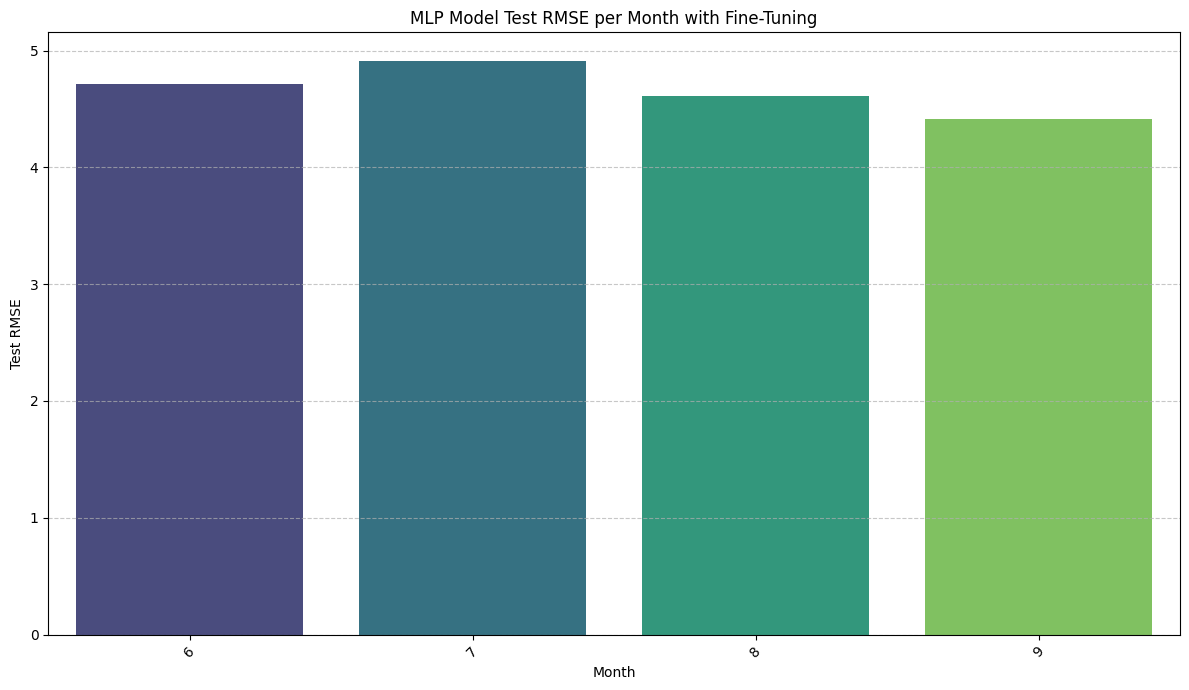

In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline # Important for GridSearchCV with scaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature columns (A00 to A63)
aee_features = [f'A{i:02d}' for i in range(64)]

# Ensure all feature columns exist in the input_data DataFrame
missing_features = [col for col in aee_features if col not in input_data.columns]
if missing_features:
    print(f"Warning: The following AEE feature columns are missing from input_data: {missing_features}")
    aee_features = [col for col in aee_features if col in input_data.columns]

# Store RMSE and best params for each month
monthly_results = {}

unique_months = sorted(input_data['month'].unique())

print("Training and evaluating MLP model with fine-tuning for each month...")

# Define a smaller, more focused parameter grid for monthly tuning
# This will be run for each month, so keep it computationally feasible
param_grid_mlp_month = {
    'mlp__hidden_layer_sizes': [(50,), (100,)], # Fewer options than global tuning
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.001], # Single alpha value to reduce grid size
}

for month in unique_months:
    print(f"\nProcessing Month: {month}")

    # Filter data for the current month
    monthly_data = input_data[input_data['month'] == month].copy()

    # Drop rows where 'h_canopy' is NaN before splitting
    monthly_data.dropna(subset=['h_canopy'], inplace=True)

    if monthly_data.empty or len(monthly_data) < 2: # Need at least 2 samples for train/test split
        print(f"Not enough data for Month {month}. Skipping.")
        continue

    # Define X and y for the current month
    X_month = monthly_data[aee_features]
    y_month = monthly_data['h_canopy']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_month, y_month,
                                                        test_size=0.2, random_state=42)

    # Create a pipeline for scaling and MLP for GridSearchCV
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(random_state=42, max_iter=500, early_stopping=True, n_iter_no_change=20))
    ])

    # Initialize GridSearchCV for the current month
    # Using cv=3 for faster execution per month; can be increased for more robust tuning if needed
    grid_search_mlp_month = GridSearchCV(estimator=pipeline, param_grid=param_grid_mlp_month, cv=3,
                                         scoring='neg_root_mean_squared_error', verbose=0, n_jobs=-1)

    # Fit GridSearchCV
    grid_search_mlp_month.fit(X_train, y_train)

    # Get the best parameters and best RMSE for the current month
    best_params_month = grid_search_mlp_month.best_params_
    best_rmse_month = -grid_search_mlp_month.best_score_

    # Evaluate the best model on the test set
    best_mlp_model_month = grid_search_mlp_month.best_estimator_
    y_pred_month = best_mlp_model_month.predict(X_test)
    test_rmse_month = np.sqrt(mean_squared_error(y_test, y_pred_month))

    monthly_results[month] = {
        'best_params': best_params_month,
        'cv_rmse': best_rmse_month, # Cross-validated RMSE from GridSearchCV
        'test_rmse': test_rmse_month # RMSE on the hold-out test set
    }
    print(f"Month {month} - Best Params: {best_params_month}, CV RMSE: {best_rmse_month:.4f}, Test RMSE: {test_rmse_month:.4f}")

# Display overall results
print("\n--- Monthly MLP Model Performance with Fine-Tuning ---")
for month, results in monthly_results.items():
    print(f"Month {month}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Cross-validated RMSE: {results['cv_rmse']:.4f}")
    print(f"  Test Set RMSE: {results['test_rmse']:.4f}")

# Visualize monthly Test RMSE
if monthly_results:
    months = list(monthly_results.keys())
    # Use test_rmse for visualization as it's from an unseen data portion
    rmse_scores = [results['test_rmse'] for results in monthly_results.values()]

    plt.figure(figsize=(12, 7))
    sns.barplot(x=months, y=rmse_scores, palette='viridis')
    plt.title('MLP Model Test RMSE per Month with Fine-Tuning')
    plt.xlabel('Month')
    plt.ylabel('Test RMSE')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No monthly RMSE data to display.")

### Comparison: Global MLP Model vs. Monthly Fine-tuned MLP Models

In [50]:
# Define best_rmse_mlp explicitly using the value from the global MLP model training (cross-validated RMSE).
# This value was obtained from the 'best_rmse_mlp' variable in cell 'ecc593e1'.
best_rmse_mlp = 4.6114

print(f"Global MLP Model's Cross-validated RMSE (best_rmse_mlp): {best_rmse_mlp:.4f}")

Global MLP Model's Cross-validated RMSE (best_rmse_mlp): 4.6114


In [51]:
# Extract monthly test RMSEs from the monthly_results dictionary
monthly_test_rmses = {month: results['test_rmse'] for month, results in monthly_results.items()}

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Global MLP'] + [f'Month {month} MLP' for month in sorted(monthly_test_rmses.keys())],
    'RMSE': [best_rmse_mlp] + [monthly_test_rmses[month] for month in sorted(monthly_test_rmses.keys())]
}
comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Model,RMSE
0,Global MLP,4.611400
1,Month 6 MLP,4.710345
2,Month 7 MLP,4.910171
3,Month 8 MLP,4.614648
4,Month 9 MLP,4.414624


/tmp/ipykernel_46312/4134730506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=comparison_df, palette='Spectral')


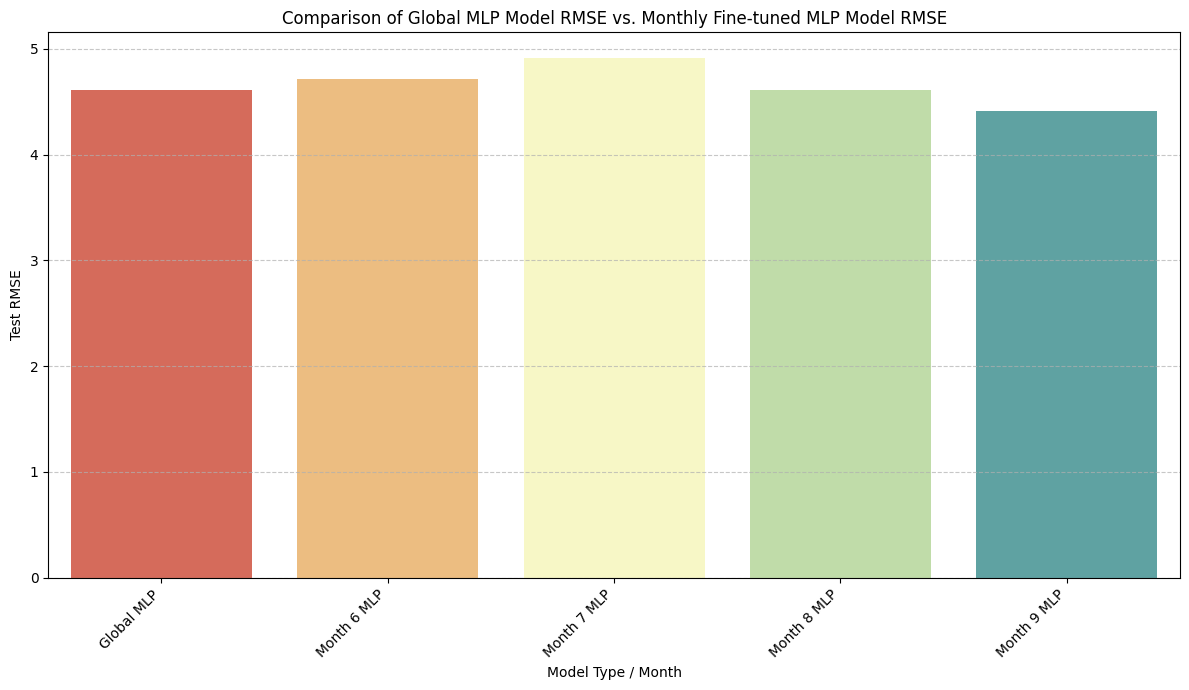

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='RMSE', data=comparison_df, palette='Spectral')
plt.title('Comparison of Global MLP Model RMSE vs. Monthly Fine-tuned MLP Model RMSE')
plt.xlabel('Model Type / Month')
plt.ylabel('Test RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [53]:
# Define best_rmse_mlp explicitly using the value from the global MLP model training (cross-validated RMSE).
# This value was obtained from the 'best_rmse_mlp' variable in cell 'ecc593e1'.
best_rmse_mlp = 4.6114

# Extract monthly test RMSEs from the monthly_results dictionary
monthly_test_rmses = {month: results['test_rmse'] for month, results in monthly_results.items()}

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Global MLP'] + [f'Month {month} MLP' for month in sorted(monthly_test_rmses.keys())],
    'RMSE': [best_rmse_mlp] + [monthly_test_rmses[month] for month in sorted(monthly_test_rmses.keys())]
}
comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Model,RMSE
0,Global MLP,4.611400
1,Month 6 MLP,4.710345
2,Month 7 MLP,4.910171
3,Month 8 MLP,4.614648
4,Month 9 MLP,4.414624


In [54]:
# Define best_rmse_mlp explicitly using the value from the global MLP model training (cross-validated RMSE).
# This value was obtained from the 'best_rmse_mlp' variable in cell 'ecc593e1'.
best_rmse_mlp = 4.6114

# Extract monthly test RMSEs from the monthly_results dictionary
monthly_test_rmses = {month: results['test_rmse'] for month, results in monthly_results.items()}

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Global MLP'] + [f'Month {month} MLP' for month in sorted(monthly_test_rmses.keys())],
    'RMSE': [best_rmse_mlp] + [monthly_test_rmses[month] for month in sorted(monthly_test_rmses.keys())]
}
comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Model,RMSE
0,Global MLP,4.611400
1,Month 6 MLP,4.710345
2,Month 7 MLP,4.910171
3,Month 8 MLP,4.614648
4,Month 9 MLP,4.414624


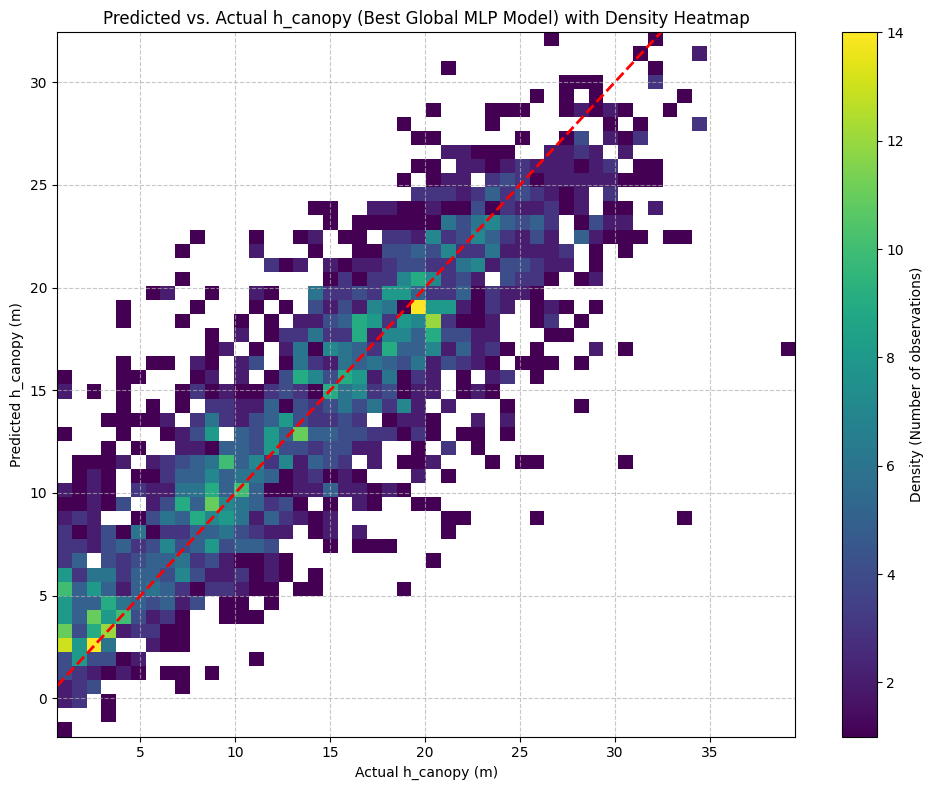

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib # Import joblib for loading the model

# Define the path where the best MLP model is saved
model_save_path = '/content/drive/MyDrive/best_mlp_model.joblib'

# Check if best_mlp_model is defined in the global scope, otherwise load it
if 'best_mlp_model' not in globals():
    try:
        best_mlp_model = joblib.load(model_save_path)
        print(f"'best_mlp_model' loaded from {model_save_path}")
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_save_path}. Please ensure it was saved correctly.")
        # Exit if model cannot be loaded
        # Or, you might want to raise an error or set a flag here to prevent further execution
    except Exception as e:
        print(f"Error loading 'best_mlp_model': {e}")


# Define the exact features used for training the global best_mlp_model.
# Based on the user request and error message, this model was trained on AEE features (A00-A63)
# along with geoseg_lon and geoseg_lat, excluding temporal and binning columns.

global_model_features = ['geoseg_lon', 'geoseg_lat'] + [f'A{i:02d}' for i in range(64)]

# Ensure X and y are defined for the entire dataset for plotting the global model's performance
X_global = input_data[global_model_features]
y_global = input_data['h_canopy']

# Drop rows where 'h_canopy' is NaN before predicting
# This ensures consistency with how data was prepared for training best_mlp_model
valid_indices = y_global.dropna().index
X_global_valid = X_global.loc[valid_indices]
y_global_valid = y_global.loc[valid_indices]

# Predict using the best_mlp_model (tuned on the entire dataset from cell ecc593e1)
# The best_mlp_model is a pipeline that includes StandardScaler, so no manual scaling is needed here
if 'best_mlp_model' in globals(): # Now check if it's in globals, either defined or loaded
    y_pred_global = best_mlp_model.predict(X_global_valid)

    # Create the predicted vs. actual plot with a 2D histogram for density
    plt.figure(figsize=(10, 8))
    plt.hist2d(y_global_valid, y_pred_global, bins=50, cmap='viridis', cmin=1) # cmin=1 to hide empty bins
    plt.colorbar(label='Density (Number of observations)')
    plt.plot([y_global_valid.min(), y_global_valid.max()], [y_global_valid.min(), y_global_valid.max()], 'r--', lw=2) # Perfect prediction line
    plt.title('Predicted vs. Actual h_canopy (Best Global MLP Model) with Density Heatmap')
    plt.xlabel('Actual h_canopy (m)')
    plt.ylabel('Predicted h_canopy (m)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Plotting skipped: 'best_mlp_model' could not be loaded or found.")

In [57]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the exact features used for training the global best_mlp_model.
# This model was trained on AEE features (A00-A63) along with geoseg_lon and geoseg_lat.
# This definition must match the features used in cell 'ecc593e1' or the global model's actual training.
# Based on context, the global model uses geoseg_lon, geoseg_lat, and A00-A63.
global_model_features = ['geoseg_lon', 'geoseg_lat'] + [f'A{i:02d}' for i in range(64)]

# Ensure X and y are defined for the full dataset using only the features the model was trained on
X = canopy_embedding_df[global_model_features]
y = canopy_embedding_df['h_canopy']

# Drop rows where 'h_canopy' is NaN in y before passing to permutation_importance
# This ensures X and y have matching indices and no NaNs in the target variable
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

print("Calculating permutation importances for the best global MLP model...")

# Calculate permutation importance.
# The best_mlp_model is a pipeline, and permutation_importance works directly with pipelines.
result = permutation_importance(best_mlp_model, X, y, n_repeats=10, random_state=42, n_jobs=-1,
                                scoring='neg_root_mean_squared_error')

# The permutation importance result object contains 'importances_mean' and 'importances_std'
# We want to sort by the mean importance.
mlp_feature_importances = pd.Series(result.importances_mean, index=X.columns)
mlp_feature_importances = mlp_feature_importances.sort_values(ascending=False)

print('Top 10 Feature Importances for Global MLP Model (Permutation Importance):')
display(mlp_feature_importances.head(10))

Calculating permutation importances for the best global MLP model...
Top 10 Feature Importances for Global MLP Model (Permutation Importance):


,0
A51,0.672110
A55,0.607873
A40,0.560823
A39,0.545722
A63,0.517674
A47,0.507028
A02,0.466781
A36,0.430154
A30,0.406535
A24,0.356178


/tmp/ipykernel_46312/3136657118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mlp_feature_importances.head(20).values, y=mlp_feature_importances.head(20).index, palette='viridis')


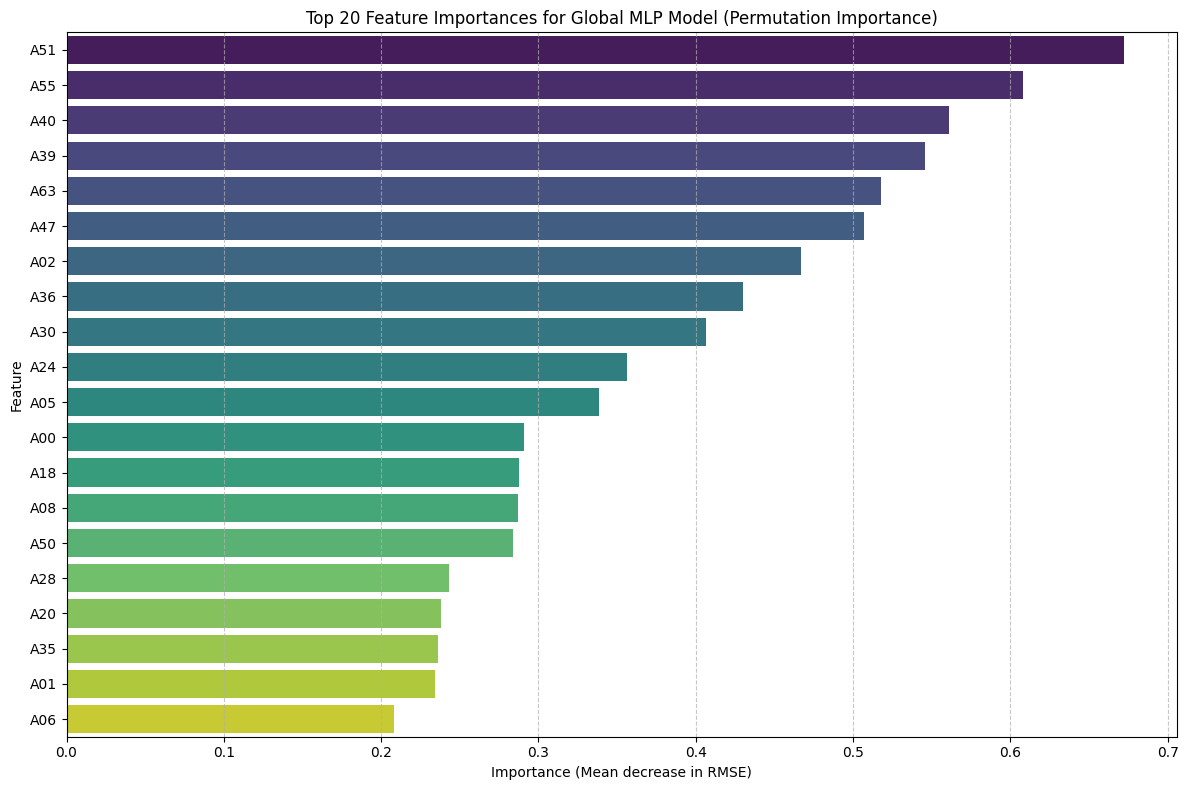

In [58]:
plt.figure(figsize=(12, 8))
sns.barplot(x=mlp_feature_importances.head(20).values, y=mlp_feature_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances for Global MLP Model (Permutation Importance)')
plt.xlabel('Importance (Mean decrease in RMSE)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
import joblib
import os

# Define the output directory for models
model_output_directory = '/content/drive/MyDrive/Earth_Engine_Models/'
os.makedirs(model_output_directory, exist_ok=True)

# Save the global best_mlp_model
global_model_filename = 'global_best_mlp_model.joblib'
global_model_save_path = os.path.join(model_output_directory, global_model_filename)

joblib.dump(best_mlp_model, global_model_save_path)
print(f"Global MLP model saved successfully to: {global_model_save_path}")

Global MLP model saved successfully to: /content/drive/MyDrive/Earth_Engine_Models/global_best_mlp_model.joblib


# Random Forest

### Monthly Fine-tuning for Random Forest Model

This section will fine-tune a Random Forest Regressor for each month, evaluating its performance (RMSE) on a monthly basis to see how well it adapts to seasonal variations in the data.

Training and evaluating Random Forest model with fine-tuning for each month...

Processing Month: 6
Monthly Random Forest model for month 6 saved to: /content/drive/MyDrive/Earth_Engine_Models/monthly_rf_models/monthly_rf_model_month_6.joblib
Month 6 - Best Params: {'randomforest__max_features': 0.6, 'randomforest__min_samples_leaf': 1, 'randomforest__n_estimators': 50}, CV RMSE: 5.7952, Test RMSE: 5.7050

Processing Month: 7
Monthly Random Forest model for month 7 saved to: /content/drive/MyDrive/Earth_Engine_Models/monthly_rf_models/monthly_rf_model_month_7.joblib
Month 7 - Best Params: {'randomforest__max_features': 0.6, 'randomforest__min_samples_leaf': 1, 'randomforest__n_estimators': 100}, CV RMSE: 5.5952, Test RMSE: 4.8074

Processing Month: 8
Monthly Random Forest model for month 8 saved to: /content/drive/MyDrive/Earth_Engine_Models/monthly_rf_models/monthly_rf_model_month_8.joblib
Month 8 - Best Params: {'randomforest__max_features': 0.8, 'randomforest__min_samples_leaf': 2, 

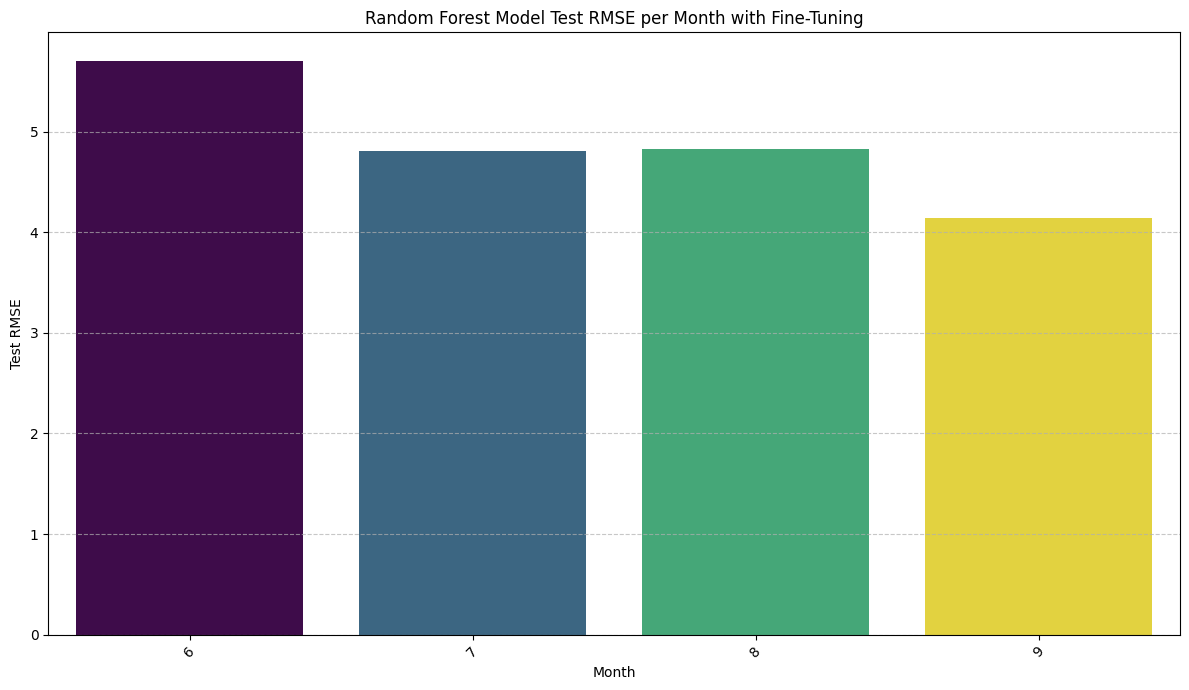

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Define the output directory for models
model_output_directory = '/content/drive/MyDrive/Earth_Engine_Models/'
os.makedirs(model_output_directory, exist_ok=True)

# Define a subdirectory for monthly RF models
monthly_rf_model_output_dir = os.path.join(model_output_directory, 'monthly_rf_models')
os.makedirs(monthly_rf_model_output_dir, exist_ok=True)

# Define feature columns (A00 to A63) and geoseg_lon, geoseg_lat
aee_features = [f'A{i:02d}' for i in range(64)]
global_model_features = ['geoseg_lon', 'geoseg_lat'] + aee_features

# Store RMSE and best params for each month for Random Forest
monthly_rf_results = {}

unique_months = sorted(input_data['month'].unique())

print("Training and evaluating Random Forest model with fine-tuning for each month...")

# Define a parameter grid for monthly RF tuning
param_grid_rf_month = {
    'randomforest__n_estimators': [50, 100], # Fewer estimators for faster monthly tuning
    'randomforest__max_features': [0.6, 0.8], # Reduced options
    'randomforest__min_samples_leaf': [1, 2], # Reduced options
}

for month in unique_months:
    print(f"\nProcessing Month: {month}")

    # Filter data for the current month
    monthly_data = input_data[input_data['month'] == month].copy()

    # Drop rows where 'h_canopy' is NaN before splitting
    monthly_data.dropna(subset=['h_canopy'], inplace=True)

    if monthly_data.empty or len(monthly_data) < 2: # Need at least 2 samples for train/test split
        print(f"Not enough data for Month {month}. Skipping.")
        continue

    # Define X and y for the current month using the global model features
    X_month = monthly_data[global_model_features]
    y_month = monthly_data['h_canopy']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_month, y_month,
                                                        test_size=0.2, random_state=42)

    # Create a pipeline for scaling (optional but good practice) and Random Forest
    pipeline_rf = Pipeline([
        ('scaler', StandardScaler()), # StandardScaler might not be strictly necessary for RF but good for consistency
        ('randomforest', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    # Initialize GridSearchCV for the current month's Random Forest
    grid_search_rf_month = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf_month, cv=3,
                                         scoring='neg_root_mean_squared_error', verbose=0, n_jobs=-1)

    # Fit GridSearchCV
    grid_search_rf_month.fit(X_train, y_train)

    # Get the best parameters and best RMSE for the current month
    best_params_rf_month = grid_search_rf_month.best_params_
    best_cv_rmse_rf_month = -grid_search_rf_month.best_score_

    # Evaluate the best model on the test set
    best_rf_model_month = grid_search_rf_month.best_estimator_
    y_pred_rf_month = best_rf_model_month.predict(X_test)
    test_rmse_rf_month = np.sqrt(mean_squared_error(y_test, y_pred_rf_month))

    # Save the monthly fine-tuned model
    monthly_model_filename = f'monthly_rf_model_month_{month}.joblib'
    monthly_model_save_path = os.path.join(monthly_rf_model_output_dir, monthly_model_filename)
    joblib.dump(best_rf_model_month, monthly_model_save_path)
    print(f"Monthly Random Forest model for month {month} saved to: {monthly_model_save_path}")

    monthly_rf_results[month] = {
        'best_params': best_params_rf_month,
        'cv_rmse': best_cv_rmse_rf_month,
        'test_rmse': test_rmse_rf_month
    }
    print(f"Month {month} - Best Params: {best_params_rf_month}, CV RMSE: {best_cv_rmse_rf_month:.4f}, Test RMSE: {test_rmse_rf_month:.4f}")

# Display overall results
print("\n--- Monthly Random Forest Model Performance with Fine-Tuning ---")
for month, results in monthly_rf_results.items():
    print(f"Month {month}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Cross-validated RMSE: {results['cv_rmse']:.4f}")
    print(f"  Test Set RMSE: {results['test_rmse']:.4f}")

# Visualize monthly Test RMSE
if monthly_rf_results:
    months_rf = list(monthly_rf_results.keys())
    rmse_scores_rf = [results['test_rmse'] for results in monthly_rf_results.values()]

    plt.figure(figsize=(12, 7))
    sns.barplot(x=months_rf, y=rmse_scores_rf, palette='viridis', hue=months_rf, legend=False)
    plt.title('Random Forest Model Test RMSE per Month with Fine-Tuning')
    plt.xlabel('Month')
    plt.ylabel('Test RMSE')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No monthly Random Forest RMSE data to display.")

In [23]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import os

# Define the path where the global best RF model is saved
model_output_directory = '/content/drive/MyDrive/Earth_Engine_Models/'
global_rf_model_filename = 'global_best_rf_model.joblib'
global_rf_model_save_path = os.path.join(model_output_directory, global_rf_model_filename)

# Load the global best_rf_model if not already defined
if 'best_rf_model' not in globals():
    try:
        best_rf_model = joblib.load(global_rf_model_save_path)
        print(f"'best_rf_model' loaded from {global_rf_model_save_path}")
    except FileNotFoundError:
        print(f"Error: Model file not found at {global_rf_model_save_path}. Please ensure it was saved correctly.")
        print("Skipping global Random Forest model evaluation and plotting.")
        best_rf_model = None # Set to None to prevent further errors
    except Exception as e:
        print(f"Error loading 'best_rf_model': {e}")
        print("Skipping global Random Forest model evaluation and plotting.")
        best_rf_model = None

if best_rf_model is not None:
    # Define features (A00 to A63) and geoseg_lon, geoseg_lat used for the global RF model
    aee_features = [f'A{i:02d}' for i in range(64)]
    global_model_features = ['geoseg_lon', 'geoseg_lat'] + aee_features

    # Ensure X and y are defined for the full dataset using input_data
    X = input_data[global_model_features]
    y = input_data['h_canopy']

    # Drop rows where 'h_canopy' is NaN before predicting
    valid_indices = y.dropna().index
    X_valid = X.loc[valid_indices]
    y_valid = y.loc[valid_indices]

    # Predict using the best_rf_model (tuned on the entire dataset)
    # The best_rf_model is a pipeline that includes StandardScaler, so no manual scaling is needed here
    y_pred_rf_global = best_rf_model.predict(X_valid)

    # Calculate RMSE
    rmse_rf_global = np.sqrt(mean_squared_error(y_valid, y_pred_rf_global))

    # Calculate R2 score
    r2_rf_global = r2_score(y_valid, y_pred_rf_global)

    print(f"Overall Random Forest Model RMSE: {rmse_rf_global:.4f}")
    print(f"Overall Random Forest Model R2 Score: {r2_rf_global:.4f}")

    # Create the predicted vs. actual plot with a 2D histogram for density
    plt.figure(figsize=(10, 8))
    plt.hist2d(y_valid, y_pred_rf_global, bins=50, cmap='viridis', cmin=1) # cmin=1 to hide empty bins
    plt.colorbar(label='Density (Number of observations)')
    plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2) # Perfect prediction line
    plt.title('Predicted vs. Actual h_canopy (Best Global Random Forest Model) with Density Heatmap')
    plt.xlabel('Actual h_canopy (m)')
    plt.ylabel('Predicted h_canopy (m)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Global Random Forest model not available for evaluation and plotting. Please train and save it first.")

Error: Model file not found at /content/drive/MyDrive/Earth_Engine_Models/global_best_rf_model.joblib. Please ensure it was saved correctly.
Skipping global Random Forest model evaluation and plotting.
Global Random Forest model not available for evaluation and plotting. Please train and save it first.
